### 异常检测
训练集：正常的数据  
验证集和测试集：正常的数据，少量异常数据

In [1]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt

In [2]:
mat=sio.loadmat('data/ex8data1.mat')
mat.keys()

dict_keys(['__header__', '__version__', '__globals__', 'X', 'Xval', 'yval'])

In [3]:
X=mat['X']
Xval,yval=mat['Xval'],mat['yval']
X.shape,Xval.shape,yval.shape

((307, 2), (307, 2), (307, 1))

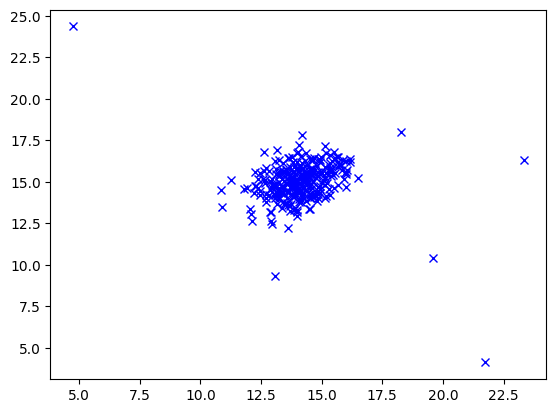

In [4]:
plt.plot(X[:,0],X[:,1],'bx')
plt.show()

### 获取训练集中样本特征的均值和方差

**方差**（Variance）是衡量单个随机变量离散程度（dispersion）的指标，表示数据点偏离其均值的平均平方距离。简单来说，它告诉你数据的“波动”有多大。

**协方差**（Covariance）衡量两个随机变量 ( X ) 和 ( Y ) 如何一起变化，表示它们偏离各自均值的联合波动。简单来说，它告诉你两者是“同向”还是“反向”移动。

In [5]:
def estimateGaussian(X,isCovariance):
    means=np.mean(X,axis=0)
    if isCovariance:
        sigma2=(X-means).T@(X-means)/len(X)
    else:
        sigma2=np.var(X,axis=0)
    return means,sigma2

In [6]:
means,sigma2=estimateGaussian(X,isCovariance=True)
sigma2

array([[ 1.83263141, -0.22712233],
       [-0.22712233,  1.70974533]])

In [7]:
means,sigma2=estimateGaussian(X,isCovariance=False)
sigma2

array([1.83263141, 1.70974533])

### 多元正态分布密度函数
均值：
$$
μ_i=\frac{1}{m}\sum_{j=1}^m x_i^{(j)}
$$
方差
$$
σ_i^2=\frac{1}{m}\sum_{j=1}^{m}(x_i^{(j)}-μ_i)^2
$$
密度函数
$$
p(x;μ;σ)=\prod_{j=1}^n \frac{1}{\sqrt{2\pi}\sigma_j} exp(-\frac{(x_j-μ_j)^2}{2\sigma_j^2})
$$

In [8]:
def gaussian(X,means,sigma2):
    if np.ndim(sigma2)==1:#一维
        sigma2=np.diag(sigma2)
    X=X-means
    n=X.shape[1]

    first=np.power(2*np.pi,-n/2)*(np.linalg.det(sigma2)**(-0.5))
    second=np.diag(X@np.linalg.inv(sigma2)@X.T)
    p=first*np.exp(-0.5*second)
    p=p.reshape(-1,1)

    return p

### 绘图

In [9]:
def plotGaussian(X,means,sigma2):
    x=np.arange(0,30,0.5)
    y=np.arange(0,30,0.5)
    xx,yy=np.meshgrid(x,y)
    z=gaussian(np.c_[xx.ravel(),yy.ravel()],means,sigma2)
    zz=z.reshape(xx.shape)

    plt.plot(X[:,0],X[:,1],'bx')
    contour_levels=[10**h for h in range(-20,0,3)]
    plt.contour(xx,yy,zz,contour_levels)

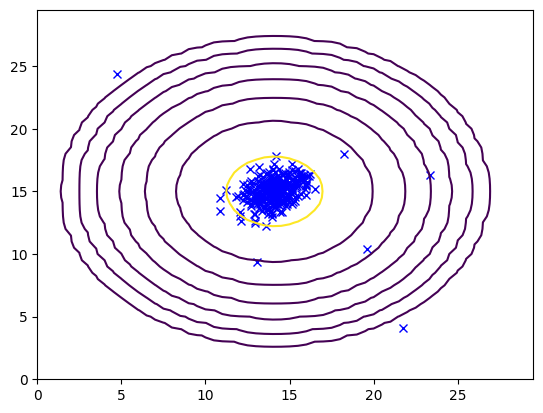

In [10]:
means,sigma2=estimateGaussian(X,isCovariance=False)
plotGaussian(X,means,sigma2)

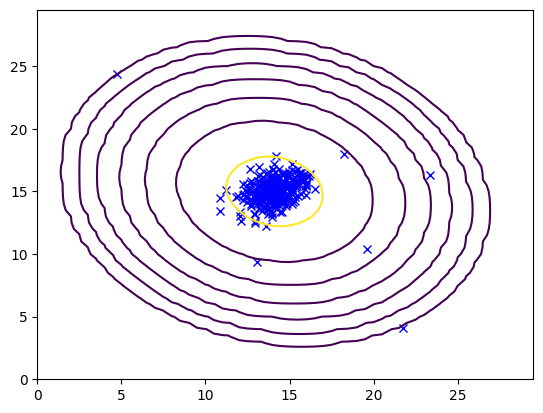

In [11]:
means,sigma2=estimateGaussian(X,isCovariance=True)
plotGaussian(X,means,sigma2)

### 阈值epsilon选取

In [12]:
def selectThreshold(yval,p):
    bestEpsilon=0
    bestF1=0
    epsilons=np.linspace(min(p),max(p),1000)
    for e in epsilons:
        p_=p<e#异常点
        tp=np.sum((yval==1)&(p_==1))#实际是1预测也是1
        fp=np.sum((yval==0)&(p_==1))
        fn=np.sum((yval==1)&(p_==0))
        prec=tp/(tp+fp) if (tp+fp) else 0
        rec=tp/(tp+fn) if (tp+fn) else 0
        F1_e=2*prec*rec/(prec+rec) if (prec+rec) else 0

        if F1_e>bestF1:
            bestF1=F1_e
            bestEpsilon=e
    return bestEpsilon,bestF1

In [13]:
means,sigma2=estimateGaussian(X,isCovariance=True)
pval=gaussian(Xval,means,sigma2)
bestEpsilon,bestF1=selectThreshold(yval,pval)

In [14]:
bestEpsilon,bestF1

(array([9.07484457e-05]), np.float64(0.8750000000000001))

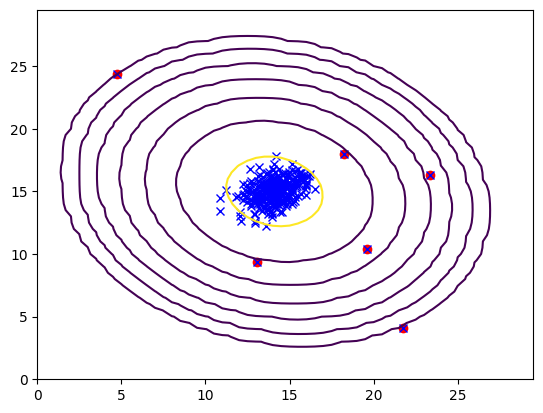

In [15]:
p=gaussian(X,means,sigma2)
anoms=np.array([X[i] for i in range(X.shape[0]) if p[i]<bestEpsilon])
plotGaussian(X,means,sigma2)
plt.scatter(anoms[:,0],anoms[:,1],c='r',marker='o')